<a href="https://colab.research.google.com/github/EKANATH9/VRSU/blob/main/Program-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

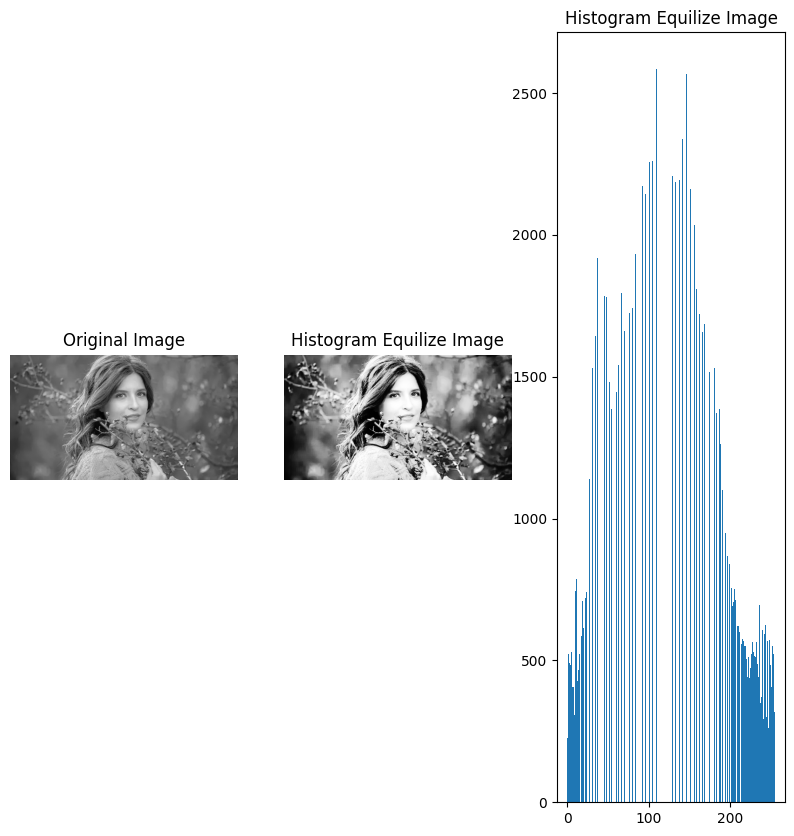

In [ ]:
#point processing
#Histrogram equilization

import cv2
from matplotlib import pyplot as plt

#load image in grayscale
img = cv2.imread('/content/sample_data/greythird.webp',0)

#Apply Histogram equilization
he_img = cv2.equalizeHist(img)

#Display Results
plt.figure(figsize=(10,10))

plt.subplot(1,3,1)
plt.imshow(img,cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(he_img,cmap='gray')
plt.title('Histogram Equilize Image')
plt.axis('off')

plt.subplot(1,3,3)
plt.title('Histogram Equilize Image')
plt.hist(he_img.ravel(),256)
plt.show()


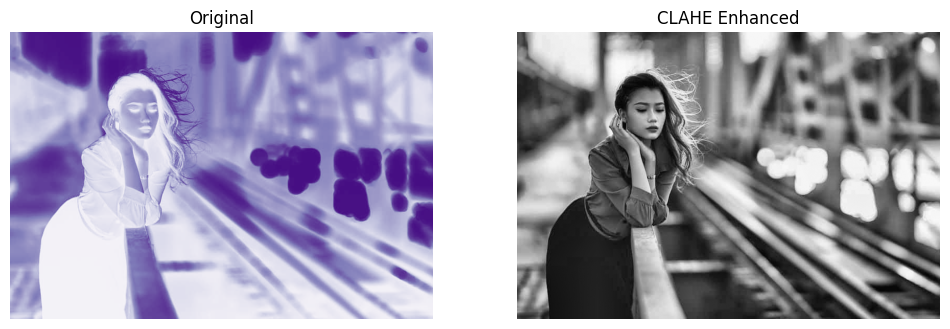

In [ ]:
#Point Processing
#CLAHE
import cv2
import matplotlib.pyplot as plt
# Load grayscale image
img = cv2.imread("/content/sample_data/most-beautiful-women1.jpg", 0)
# Create CLAHE object
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
# Apply enhancement
clahe_img = clahe.apply(img)
# Plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img,cmap='Purples')
plt.axis("off")
plt.subplot(1,2,2)
plt.title("CLAHE Enhanced")
plt.imshow(clahe_img, cmap='gray')
plt.axis("off")

plt.show()


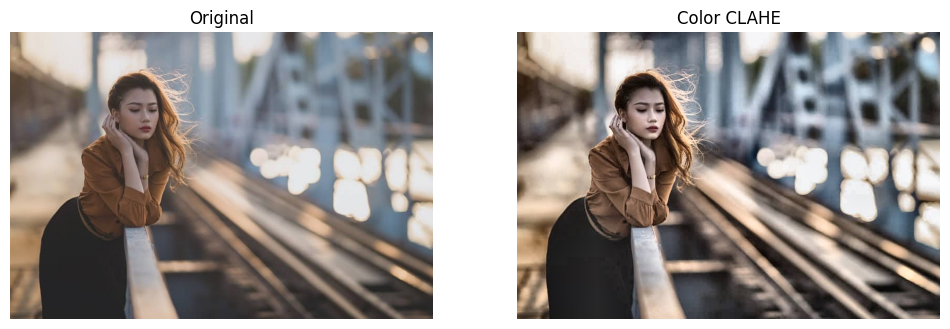

In [ ]:
#Point Processing
#color Enhancement
import cv2
import matplotlib.pyplot as plt
img = cv2.imread("/content/sample_data/most-beautiful-women1.jpg")
img_ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
# Split Y, Cr, Cb
Y, Cr, Cb = cv2.split(img_ycrcb)
# CLAHE on Y channel
clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8,8))
Y_clahe = clahe.apply(Y)
# Merge & convert back
img_clahe = cv2.merge((Y_clahe, Cr, Cb))
img_clahe = cv2.cvtColor(img_clahe, cv2.COLOR_YCrCb2BGR)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.subplot(1,2,2)
plt.title("Color CLAHE")
plt.imshow(cv2.cvtColor(img_clahe, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


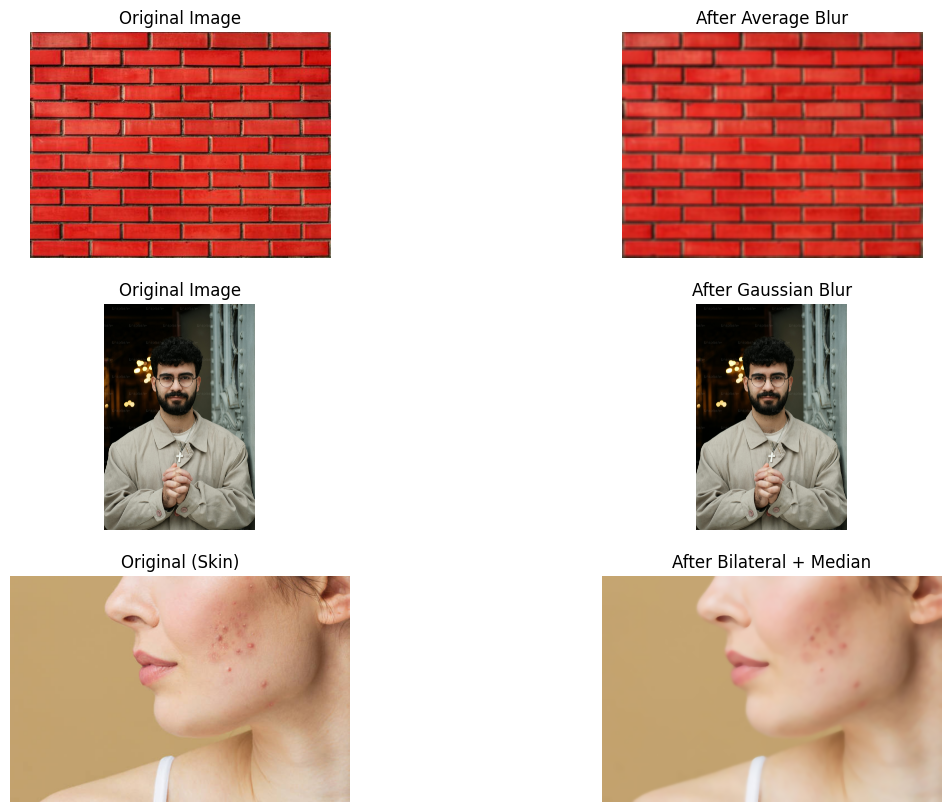

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# -----------------------------
# Load 3 different images
# -----------------------------
img_avg = cv2.imread('/content/sample_data/brick-wall-texture-red-brick-loft-back-photo.jpg')
img_gauss = cv2.imread('/content/sample_data/premium_photo-1678197937465-bdbc4ed95815.jpg')
img_med = cv2.imread('/content/sample_data/istockphoto-1352124035-612x612.jpg')

# Check if images loaded properly
if img_avg is None or img_gauss is None or img_med is None:
    print('Error: One or more images not found. Check file paths!')

# Convert BGR → RGB (matplotlib expects RGB, OpenCV loads BGR)
img_avg_rgb = cv2.cvtColor(img_avg, cv2.COLOR_BGR2RGB)
img_gauss_rgb = cv2.cvtColor(img_gauss, cv2.COLOR_BGR2RGB)
img_med_rgb = cv2.cvtColor(img_med, cv2.COLOR_BGR2RGB)

"""
-----------------------------------------
Apply Filters
-----------------------------------------
"""

# 1. Average Smoothing
# Uses a 5x5 kernel → replaces each pixel with average of neighbors (simple blur)
avg_blur_bgr = cv2.blur(img_avg, (5,5))
avg_blur_rgb = cv2.cvtColor(avg_blur_bgr, cv2.COLOR_BGR2RGB)

# 2. Gaussian Smoothing
# (9x9) kernel + sigma=3 → stronger blur with Gaussian weight distribution
gaussian_blur_bgr = cv2.GaussianBlur(img_gauss, (9,9), 3)
gaussian_blur_rgb = cv2.cvtColor(gaussian_blur_bgr, cv2.COLOR_BGR2RGB)

# 3. Skin Smoothing (Improved Median Blur)
# Bilateral filter:
# d=9 → neighborhood size
# sigmaColor=100 → smooths color variations (pimples)
# sigmaSpace=100 → smooths spatial area while preserving edges
bilateral = cv2.bilateralFilter(img_med, d=9, sigmaColor=100, sigmaSpace=100)

# Median blur (kernel=7) removes remaining small spots/noise
median = cv2.medianBlur(bilateral, 7)

skin_smooth_rgb = cv2.cvtColor(median, cv2.COLOR_BGR2RGB)

"""
-------------------------------------------
Display Before and After for each filter
-------------------------------------------
"""

plt.figure(figsize=(14,10))

# -------- Average Blur --------
plt.subplot(3,2,1)
plt.imshow(img_avg_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(3,2,2)
plt.imshow(avg_blur_rgb)
plt.title('After Average Blur')
plt.axis('off')

# -------- Gaussian Blur --------
plt.subplot(3,2,3)
plt.imshow(img_gauss_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(3,2,4)
plt.imshow(gaussian_blur_rgb)
plt.title('After Gaussian Blur')
plt.axis('off')

# ----- Median + Bilateral ------
plt.subplot(3,2,5)
plt.imshow(img_med_rgb)
plt.title('Original (Skin)')
plt.axis('off')

plt.subplot(3,2,6)
plt.imshow(skin_smooth_rgb)
plt.title('After Bilateral + Median')
plt.axis('off')

# REQUIRED to render all subplots
plt.show()

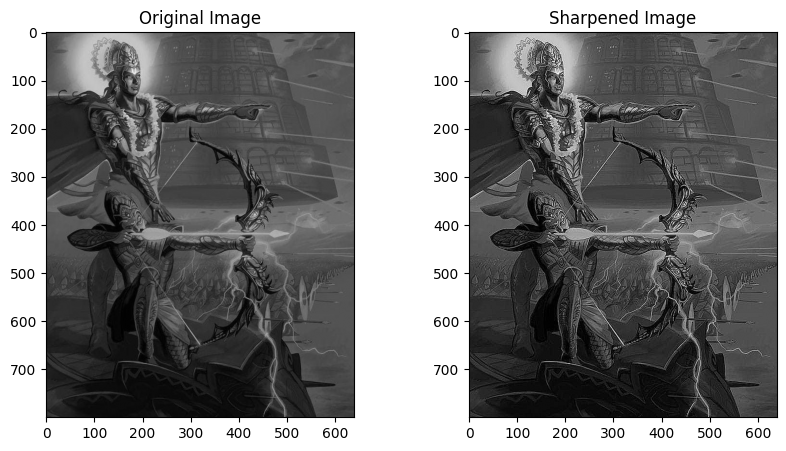

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
#Load image in greyscale
img = cv2.imread('/content/sample_data/8d709a96a3c6539e671701ba55c6cad9.jpg',0)
#Sharpeing kernel (simple 3x3 filter)
kernel = np.array([[0,-1,0],
                   [-1,5,-1],
                   [0,-1,0]])
#Apply Sharpening
sharpened_img = cv2.filter2D(img,-1,kernel)
#Show original and sharpend images
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title('Original Image')
plt.axis('on')
plt.subplot(1,2,2)
plt.imshow(sharpened_img,cmap='gray')
plt.title('Sharpened Image')
plt.axis('on')
plt.show()

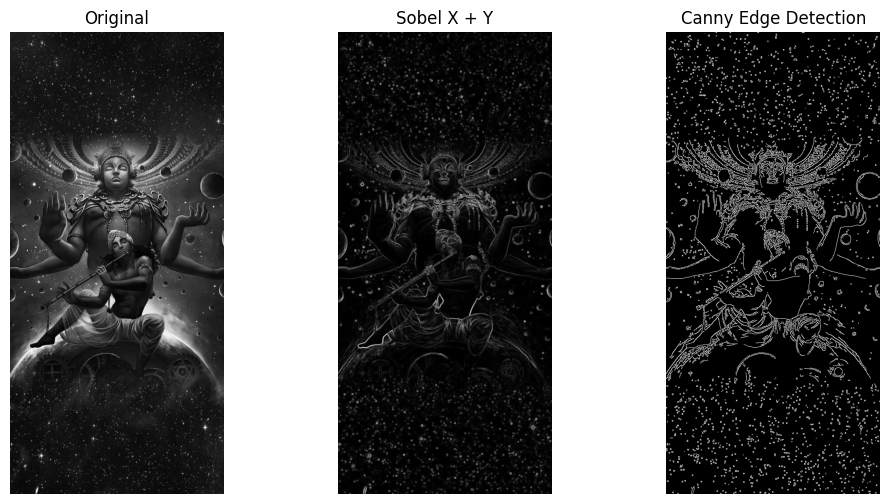

In [ ]:
#	Spatial Domain Filtering
# Edge Detection
import cv2
import matplotlib.pyplot as plt

# Load image
img = cv2.imread("/content/sample_data/b7f148de1b43cf5bbb9f343bce95154b.jpg", 0)

# 1. Sobel Edge Detection
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3) # vertical edges
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3) # Horizontal edges
sobel_xy = cv2.magnitude(sobel_x, sobel_y)

# 2. Canny Edge Detector
canny_edges = cv2.Canny(img, 100, 200)

# Display
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Sobel X + Y")
plt.imshow(sobel_xy, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Canny Edge Detection")
plt.imshow(canny_edges, cmap='gray')
plt.axis('off')

plt.show()
